<a href="https://colab.research.google.com/github/NikitaZolin101/Portfolio_Python/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Финальный проект

# A/B-тестирование персонализированного баннера рекомендаций

## Notebook 1. Исследовательский анализ данных (EDA)

### Автор
Никита Золин

## Цель исследования
Провести исследовательский анализ исторических данных пользователей стримингового сервиса для подготовки к проектированию A/B-теста.


## 1. Импорт библиотек

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"]=(10,5)


## 2. Загрузка данных

In [7]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Финальный проект/stream_events.csv')
df.head()

,dt,client_id,event_type,content_id,watch_time_min
0,2025-04-19 13:02:27,1025,click_banner,126,NaN
1,2025-04-07 11:21:16,1754,view_banner,380,NaN
2,2025-04-26 20:57:25,1089,click_banner,17,NaN
3,2025-04-01 20:44:19,1223,view_banner,309,NaN
4,2025-04-01 18:28:08,1203,click_banner,360,NaN


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df.sample(5, random_state=42)

,dt,client_id,event_type,content_id,watch_time_min
83,2025-04-16 14:11:36,1518,view_banner,478,NaN
53,2025-04-25 22:18:22,1072,click_banner,143,NaN
70,2025-04-17 02:48:53,1735,view_banner,98,NaN
45,2025-04-04 17:21:37,1486,finish_watch,85,68.00
44,2025-04-24 15:57:07,1778,click_banner,65,NaN


## 3. Общая информация

In [10]:
pd.DataFrame({
    "Показатель":["Количество строк","Количество столбцов"],
    "Значение":[df.shape[0], df.shape[1]]
})

,Показатель,Значение
0,Количество строк,100
1,Количество столбцов,5


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dt              100 non-null    object 
 1   client_id       100 non-null    int64  
 2   event_type      100 non-null    object 
 3   content_id      100 non-null    int64  
 4   watch_time_min  9 non-null      float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ KB


In [12]:
df.describe(include='all')

,dt,client_id,event_type,content_id,watch_time_min
count,100,100.00,100,100.00,9.00
unique,100,NaN,4,NaN,NaN
top,2025-04-19 13:02:27,NaN,view_banner,NaN,NaN
freq,1,NaN,48,NaN,NaN
mean,NaN,1516.81,NaN,216.25,59.33
std,NaN,285.52,NaN,147.19,38.37
min,NaN,1006.00,NaN,2.00,19.00
25%,NaN,1242.25,NaN,95.50,30.00
50%,NaN,1539.00,NaN,186.00,60.00
75%,NaN,1761.25,NaN,360.25,68.00


## 4. Проверка качества данных

In [13]:
missing=df.isna().sum().reset_index()
missing.columns=['Столбец','Количество пропусков']
missing

,Столбец,Количество пропусков
0,dt,0
1,client_id,0
2,event_type,0
3,content_id,0
4,watch_time_min,91


In [14]:
pd.DataFrame({
    "Показатель":["Количество дубликатов"],
    "Значение":[df.duplicated().sum()]
})

,Показатель,Значение
0,Количество дубликатов,0


### Промежуточный вывод

Проверены типы данных, пропуски и дубликаты. Критических проблем, препятствующих дальнейшему анализу, не выявлено.


## 5. Подготовка данных

In [15]:
df['dt']=pd.to_datetime(df['dt'])
df['date']=df['dt'].dt.date
df['hour']=df['dt'].dt.hour
df.head()

,dt,client_id,event_type,content_id,watch_time_min,date,hour
0,2025-04-19 13:02:27,1025,click_banner,126,NaN,2025-04-19,13
1,2025-04-07 11:21:16,1754,view_banner,380,NaN,2025-04-07,11
2,2025-04-26 20:57:25,1089,click_banner,17,NaN,2025-04-26,20
3,2025-04-01 20:44:19,1223,view_banner,309,NaN,2025-04-01,20
4,2025-04-01 18:28:08,1203,click_banner,360,NaN,2025-04-01,18


## 6. Анализ событий

In [16]:
event_counts=df['event_type'].value_counts().sort_values(ascending=False)
event_counts

,count
event_type,
view_banner,48
click_banner,27
start_watch,16
finish_watch,9


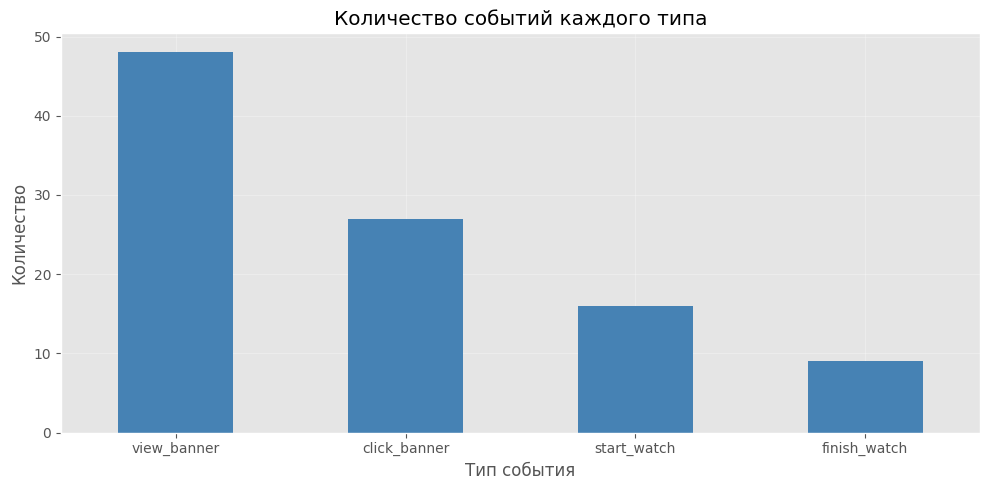

In [17]:
ax=event_counts.plot(kind='bar', color='steelblue')
ax.set_title('Количество событий каждого типа')
ax.set_xlabel('Тип события')
ax.set_ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Промежуточный вывод

Основную часть событий составляют просмотры баннера и просмотры контента.

## 7. Анализ пользователей

In [18]:
pd.DataFrame({
    "Показатель":["Количество пользователей","Количество фильмов","Начало периода","Конец периода"],
    "Значение":[df.client_id.nunique(), df.content_id.nunique(), df.dt.min(), df.dt.max()]
})

,Показатель,Значение
0,Количество пользователей,95
1,Количество фильмов,94
2,Начало периода,2025-04-01 06:29:00
3,Конец периода,2025-04-29 12:58:44


## 8. Активность пользователей

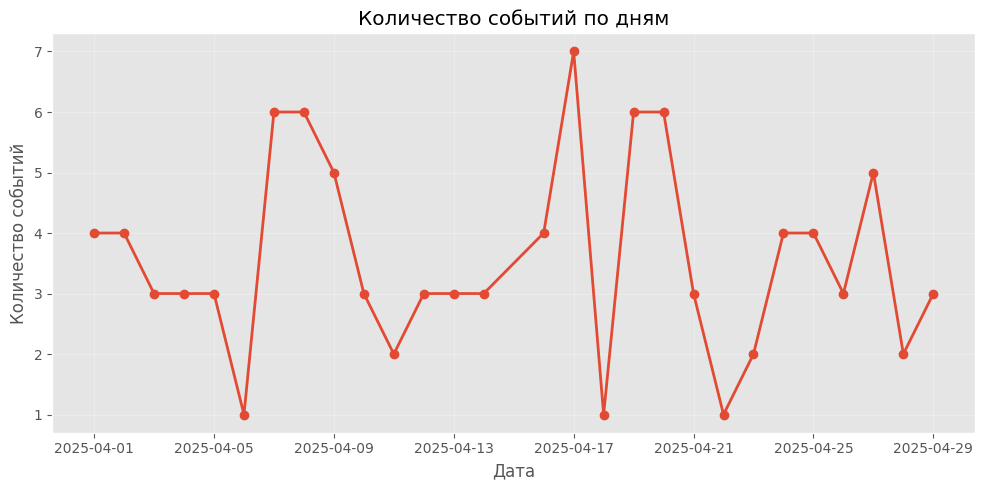

In [19]:
events_by_day=df.groupby('date').size()
ax=events_by_day.plot(marker='o', linewidth=2)
ax.set_title('Количество событий по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество событий')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Наиболее активные пользователи

In [20]:
top_users=df.groupby('client_id').size().sort_values(ascending=False).head(10)
top_users

,0
client_id,
1114,2
1225,2
1882,2
1826,2
1881,2
1069,1
1025,1
1080,1
1089,1


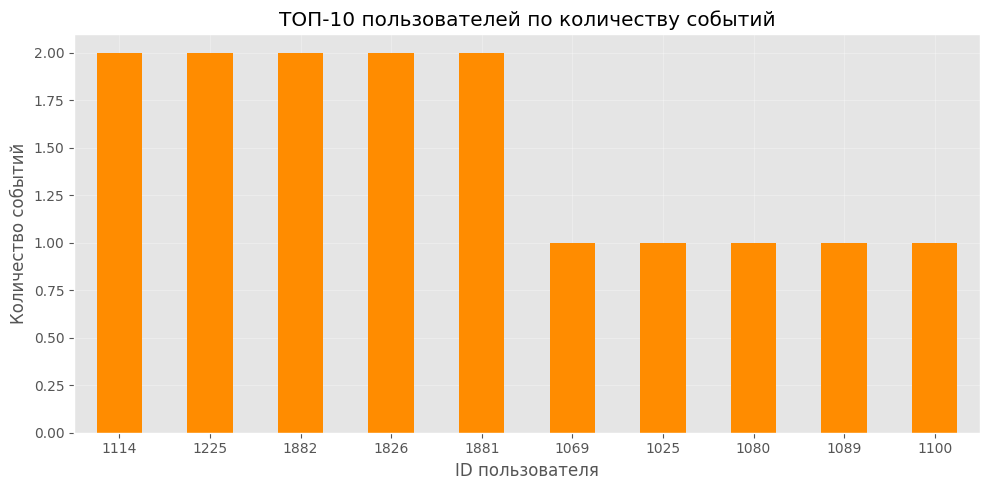

In [21]:
ax=top_users.plot(kind='bar', color='darkorange')
ax.set_title('ТОП-10 пользователей по количеству событий')
ax.set_xlabel('ID пользователя')
ax.set_ylabel('Количество событий')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Проверка структуры событий

In [22]:
events=pd.DataFrame({
'Событие':['view_banner','click_banner','start_watch','finish_watch','add_to_favorites'],
'Присутствует':[e in df.event_type.unique() for e in ['view_banner','click_banner','start_watch','finish_watch','add_to_favorites']]
})
events

,Событие,Присутствует
0,view_banner,True
1,click_banner,True
2,start_watch,True
3,finish_watch,True
4,add_to_favorites,False


# Итоговый вывод

Выполнен исследовательский анализ данных. Проверено качество данных, исследованы пользовательские события и активность пользователей. Установлено отсутствие событий `add_to_favorites`, поэтому метрика CR_fav будет рассчитана только на этапе моделирования результатов эксперимента.
